# Create figures relating to LEFM

This notebook generates the figures relating to the LEFM processing. 

 - Figure 4
 - Figure 5
 - Figure S6


In [1]:
import os

import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri

from lefm import find_crevasse_depths, calculate_K_I, calculate_K_1, calculate_K_2, calculate_K_3, F_ds_H
from funcs import add_panel_label

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 8
plt.rcParams['mathtext.fontset'] = 'cm' # Use latex-style fonts for equations

%matplotlib widget


## Set up parameters (Fig. S6)

In [2]:

timesteps = 1000
H = 1000

dwmin, dwmax = 0, 1000
d_w1  = dwmin
d_w2  = np.arange(dwmin, dwmax, (dwmax-dwmin)/timesteps)
d_w3  = dwmax
df_d_w = pd.DataFrame({'1': d_w1, '2': d_w2, '3': d_w3})

rxxmin, rxxmax = -100e3, +400e3
R_xxA = rxxmin
R_xxB = np.arange(rxxmin, rxxmax, (rxxmax-rxxmin)/timesteps)
R_xxC = rxxmax
df_r_xx = pd.DataFrame({'A': R_xxA, 'B': R_xxB, 'C': R_xxC})


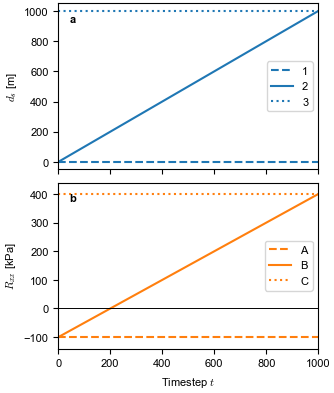

In [3]:

plt.close()

mm = 1/25.4  # centimeters in inches
fig, axes = plt.subplots(figsize=(85*mm, 100*mm), layout='constrained', nrows=2, sharex=True) # 180 mm wide

x = range(len(d_w2))

ax = axes[0]
ax.plot(x, np.full_like(d_w2, d_w1), color='tab:blue', ls='--', label='1')
ax.plot(x, d_w2, color='tab:blue', ls='-', label='2')
ax.plot(x, np.full_like(d_w2, d_w3), color='tab:blue', ls=':', label='3')
ax.set_ylabel(r'$d_s$ [m]')
ax.legend(loc='center right')
ax.set_ylim(-50, 1050)
add_panel_label(ax, 'a', loc='top left', offset=2*mm, weight='bold', color='k')

ax = axes[1]
ax.plot(x, np.full_like(R_xxB, R_xxA)/1e3, color='tab:orange', ls='--', label='A')
ax.plot(x, R_xxB/1e3, color='tab:orange', ls='-', label='B')
ax.plot(x, np.full_like(R_xxB, R_xxC)/1e3, color='tab:orange', ls=':', label='C')
ax.set_ylabel(r'$R_{xx}$ [kPa]')
ax.set_xlabel(r'Timestep $t$')
ax.legend(loc='center right')
ax.set_xlim(0, 1000)
ax.set_ylim(-140e3/1e3, 440e3/1e3)
ax.axhline(0, lw=.7, color='k')
add_panel_label(ax, 'b', loc='top left', offset=2*mm, weight='bold', color='k')

# plt.savefig('../figures/figure_S5.png', dpi=300)
plt.savefig('../figures/figure_S6.jpg', dpi=600)
plt.savefig('../figures/figure_S6.pdf')


## Run for all combinations of model projections (Figure 4)

In [4]:
out_fpath = '../data/model_outputs/scenario_predicted_depths.csv'

if not os.path.exists(out_fpath):
    
    print('1A')
    d_s_1A = find_crevasse_depths(d_w1, R_xxA, H, K_Ic=0.2e6)
    
    print('2A')
    d_s_2A = find_crevasse_depths(d_w2, R_xxA, H, K_Ic=0.2e6)
    
    print('3A')
    d_s_3A = find_crevasse_depths(d_w3, R_xxA, H, K_Ic=0.2e6)
    
    print('1B')
    d_s_1B = find_crevasse_depths(d_w1, R_xxB, H, K_Ic=0.2e6)
    
    print('2B')
    d_s_2B = find_crevasse_depths(d_w2, R_xxB, H, K_Ic=0.2e6)
    
    print('3B')
    d_s_3B = find_crevasse_depths(d_w3, R_xxB, H, K_Ic=0.2e6)
    
    print('1C')
    d_s_1C = find_crevasse_depths(d_w1, R_xxC, H, K_Ic=0.2e6)
    
    print('2C')
    d_s_2C = find_crevasse_depths(d_w2, R_xxC, H, K_Ic=0.2e6)
    
    print('3C')
    d_s_3C = find_crevasse_depths(d_w3, R_xxC, H, K_Ic=0.2e6)


    # df_d_w.to_csv('inputs_d_w.csv')
    # df_r_xx.to_csv('inputs_r_xx.csv')

    df_d_s = pd.DataFrame({
        '1A':  d_s_1A,
        '2A':  d_s_2A,
        '3A':  d_s_3A,
        '1B':  d_s_1B,
        '2B':  d_s_2B,
        '3B':  d_s_3B,
        '1C':  d_s_1C,
        '2C':  d_s_2C,
        '3C':  d_s_3C,
    })

    df_d_s.to_csv(out_fpath)

else:
    
    df_d_s = pd.read_csv(out_fpath)

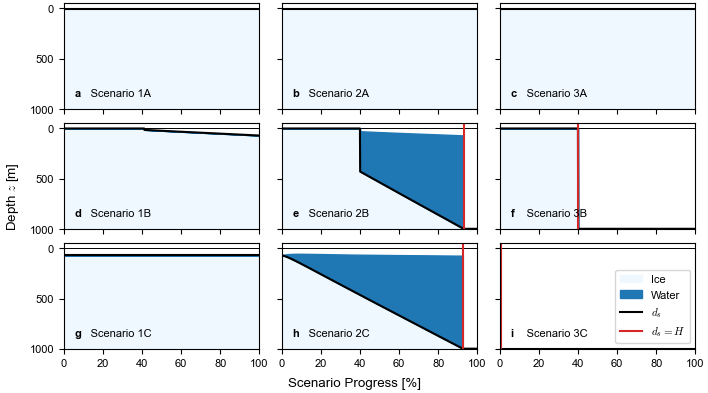

In [21]:
plt.close()

mm = 1/25.4  # centimeters in inches
fig, axes = plt.subplots(
    nrows=3, ncols=3, 
    sharex=True, sharey=True, 
    figsize=(180*mm, 100*mm),
)

def plot_crev(ax, run, d_s_arr, d_w):

    # Calculate appropriate water depth values for plotting
    d_w_z = np.clip(d_s_arr - d_w, 0, None)  # z height of water surface
    d_w_z = np.where(d_w==0, d_s_arr, d_w_z)  # account for funniness when d_w = 0
    d_w_thickness = d_s_arr - d_w_z  # water column thickness within fracture

    # Mask fractured bits
    fractured_mask = d_s_arr == H-1
    first_fracture = np.argmax(fractured_mask)
    fractured_mask[first_fracture] = False
    d_w_thickness[fractured_mask] = np.nan
    d_w_z[fractured_mask] = np.nan
    if not isinstance(d_w, (int, float)):
        d_w = d_w.copy()
        d_w[fractured_mask] = np.nan
    
    # Plot
    x = np.array(range(len(d_s_arr))) / 10
    ax.fill_between(x, 1000, d_s_arr, color='aliceblue', label='Ice')
    ax.fill_between(x, d_s_arr, d_w_z, color='tab:blue', label='Water')
    ax.plot(x, d_s_arr, c='k', label=r'$d_s$')
    
    ax.axhline(0, lw=.7, c='k')

    if not first_fracture==0:
        ax.axvline(first_fracture/10, c='tab:red', label=r'$d_s = H$')

    # ax.text(0.03, 0.03, run, transform=ax.transAxes,
    #     horizontalalignment='left', verticalalignment='bottom')

ax = axes[0,0]
run = '1A'
plot_crev(ax, run, df_d_s['1A'].values, d_w1)
# ax.set_ylabel(r'Depth $z$ [m]')# , labelpad=15)
ax.tick_params(axis='y')#, pad=15)
add_panel_label(ax, 'a', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax = axes[0,1]
run = '2A'
plot_crev(ax, run, df_d_s['2A'].values, d_w2)
add_panel_label(ax, 'b', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax = axes[0,2]
run = '3A'
plot_crev(ax, run, df_d_s['3A'].values, d_w3)
add_panel_label(ax, 'c', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax = axes[1,0]
run = '1B'
plot_crev(ax, run, df_d_s['1B'].values, d_w1)
# ax.set_ylabel(r'Depth $z$ [m]')
ax.tick_params(axis='y')#, pad=15)
add_panel_label(ax, 'd', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax = axes[1,1]
run = '2B'
plot_crev(ax, run, df_d_s['2B'].values, d_w2)
add_panel_label(ax, 'e', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax = axes[1,2]
run = '3B'
plot_crev(ax, run, df_d_s['3B'].values, d_w3)
add_panel_label(ax, 'f', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax = axes[2,0]
run = '1C'
plot_crev(ax, run, df_d_s['1C'].values, d_w1)
# ax.set_xlabel(r'Timestep $t$')
ax.tick_params(axis='x')#, pad=15)
# ax.set_ylabel(r'Depth $z$ [m]')
ax.tick_params(axis='y')#, pad=15)
add_panel_label(ax, 'g', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax = axes[2,1]
run = '2C'
plot_crev(ax, run, df_d_s['2C'].values, d_w2)
# ax.set_xlabel(r'Timestep $t$')
ax.tick_params(axis='x')#, pad=15)
add_panel_label(ax, 'h', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax = axes[2,2]
run = '3C'
plot_crev(ax, run, df_d_s['3C'].values, d_w3)
ax.axvline(.5, c='tab:red', label=r'$d_s = H$')
# ax.set_xlabel(r'Timestep $t$')
ax.tick_params(axis='x')#, pad=15)
add_panel_label(ax, 'i', loc='bottom left', offset=2*mm, weight='bold', color='k')
add_panel_label(ax, f'     Scenario {run}', loc='bottom left', offset=2*mm, weight='normal', color='k')

ax.legend(loc='lower right')

ax.set_ylim(-50, 1000)
ax.invert_yaxis()
ax.set_xlim(0, 100)

fig.supxlabel('Scenario Progress [%]')
fig.supylabel(r'Depth $z$ [m]')

# plt.savefig('../figures/figure_4.png', dpi=300)
plt.savefig('../figures/figure_4.jpg', dpi=600)
plt.savefig('../figures/figure_4.pdf', dpi=300)


In [14]:
# d_w2[930]
R_xxC

400000.0

## Run for full parameter space (Figure 5)

In [3]:

H = 1000
size = 101

dwmin, dwmax = 0, 1000
d_w = np.linspace(dwmin, dwmax, size)

rxxmin, rxxmax = -100e3, 400e3
r_xx = np.linspace(rxxmin, rxxmax, size)

d_w_grid, r_xx_grid = np.meshgrid(d_w, r_xx)


out_fpath = '../data/model_outputs/all_predicted_depths.nc'

if not os.path.exists(out_fpath):

    # this can take a while...
    d_s = find_crevasse_depths(d_w_grid, r_xx_grid, H, K_Ic=0.2e6)

    ds = xr.Dataset(
        {
            "d_s": (["d_w", "r_xx"], d_s.T)  # Define data variable
        },
        coords={
            "r_xx": r_xx/1e6,
            "d_w": d_w,
        }
    )
    
    ds = ds.where(ds.d_s)

    ds.to_netcdf(out_fpath)

else:

    ds = xr.open_dataset(out_fpath)


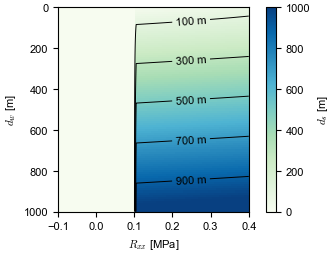

In [6]:
plt.close()

mm = 1/25.4  # centimeters in inches
fig, ax = plt.subplots(layout='constrained', figsize=(85*mm, 65*mm))

ds.d_s.plot.imshow(vmin=0, vmax=1000, cmap='GnBu', cbar_kwargs={'label': r'$d_s$ [m]'})

CS = ds.d_s.plot.contour(
    ax=ax, 
    # levels=[900, 800, 700, 600, 500, 400, 300, 200, 100, 1], #, 3, 1], 
    # levels=[900, 700, 500, 300, 100], #, 3, 1], 
    levels=[900, 700, 500, 300, 100], #, 3, 1], 
    # levels=[950, 900, 700, 500, 300, 100], 
    # levels=[980, 950, 900, 850, 800, 700, 500, 300, 100, 10], 
    colors='k', linewidths=.7
)
def fmt(x): return f'{x:.0f} m'
ax.clabel(
    CS, fontsize=8, inline_spacing=5, use_clabeltext=True, fmt=fmt, rightside_up=True,
    manual=[(0.25, 100), (0.25, 300), (0.25, 500), (0.25, 700), (0.25, 900)]
)


ax.set_ylabel('$d_w$ [m]')
ax.set_xlabel('$R_{xx}$ [MPa]')
ax.set_ylim(0, 1000)
ax.set_xlim(-.1, .4)
ax.invert_yaxis()

# plt.savefig('../figures/figure_5.png', dpi=300)
plt.savefig('../figures/figure_5.jpg', dpi=600)
plt.savefig('../figures/figure_5.pdf', dpi=300)
